--- Vista previa del DataFrame ---
   Componente 1  Componente 2  Target
0     -2.264703      0.480027  Setosa
1     -2.080961     -0.674134  Setosa
2     -2.364229     -0.341908  Setosa
3     -2.299384     -0.597395  Setosa
4     -2.389842      0.646835  Setosa




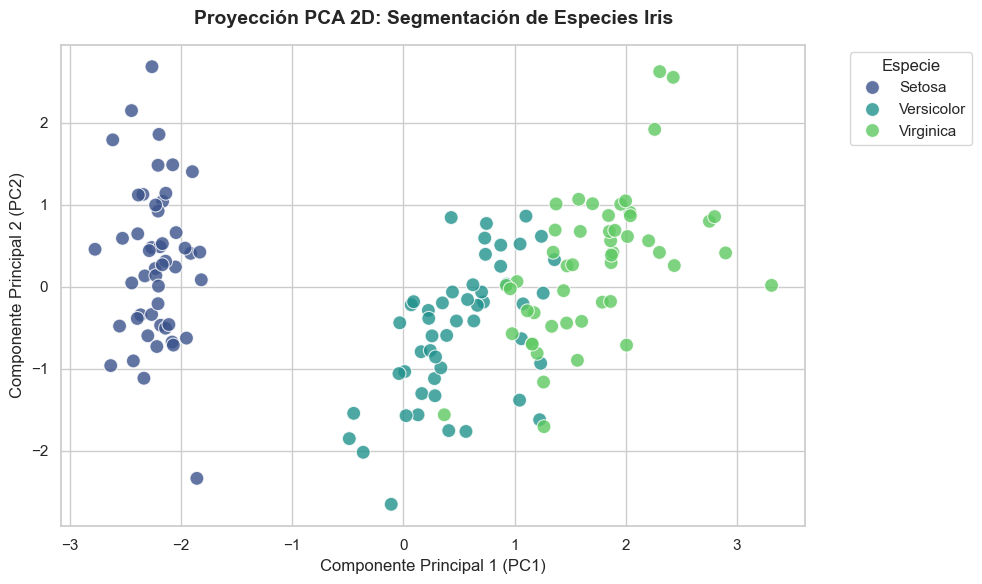

Varianza explicada por PC1: 72.96%
Varianza explicada por PC2: 22.85%
Información total retenida en 2D: 95.81%


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Carga de datos (Usando tu ruta exacta)
ruta_archivo = r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 5 Aprendizaje de máquina no supervisado\MOD 3 Reducción de dimensiones I PCA\iris.csv"
df_iris = pd.read_csv(ruta_archivo)

# 2. Separación de características (X) y variable objetivo (y)
# Tomamos todas las columnas excepto la última como 'X', y la última como nuestro 'Target'
X = df_iris.iloc[:, :-1]
y = df_iris.iloc[:, -1]

# 3. Estandarización de los datos (Regla de Oro del PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Reducción de Dimensiones con PCA
# Forzamos al algoritmo a darnos solo 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. Construcción del DataFrame (Idéntico a la rúbrica)
df_pca = pd.DataFrame(data=X_pca, columns=['Componente 1', 'Componente 2'])
df_pca['Target'] = y.values

# Mostramos las primeras filas para validar contra tu imagen de ejemplo
print("--- Vista previa del DataFrame ---")
print(df_pca.head())
print("\n")

# --- VISUALIZACIÓN EJECUTIVA ---
# Configuración de estilo limpio para reportes
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Gráfico de dispersión
sns.scatterplot(
    x='Componente 1', 
    y='Componente 2', 
    hue='Target', 
    data=df_pca, 
    palette='viridis', # Paleta de colores profesional
    s=100,             # Tamaño de los puntos
    alpha=0.8,         # Transparencia para ver puntos superpuestos
    edgecolor='w'      # Borde blanco para mayor nitidez
)

# Títulos y etiquetas sin ruido visual
plt.title('Proyección PCA 2D: Segmentación de Especies Iris', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Componente Principal 1 (PC1)', fontsize=12)
plt.ylabel('Componente Principal 2 (PC2)', fontsize=12)

# Ajuste de la leyenda fuera del gráfico
plt.legend(title='Especie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Previene que se corten los bordes al exportar la imagen

# Mostrar gráfico
plt.show()

# --- VALIDACIÓN MATEMÁTICA (EXTRA PARA TU REPORTE) ---
varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {varianza[1]*100:.2f}%")
print(f"Información total retenida en 2D: {sum(varianza)*100:.2f}%")